In [1]:
suppressMessages({
    library(ArchR)
    library(dplyr)
    library(ggplot2)
    library(ggrepel)
    set.seed(1234)
    addArchRGenome("hg38")
})


In [2]:
Gal <- loadArchRProject(path = "../output/Gal_preprocessed")


Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
metadata <- read.csv("../output/Gal_KI36_meta.csv", row.names = 1)

In [4]:
idxSample <- BiocGenerics::which(Gal$cellNames %in% rownames(metadata))
cellsSample <- Gal$cellNames[idxSample]
Gal_KI36 <- Gal[cellsSample, ]
metadata <- metadata[Gal_KI36$cellNames,]

In [5]:
Gal_KI36$clonotype <- metadata$allele_snn_res.0.02 #0 => C1; 1=> C3; 2/3 => C2

In [6]:
Gal_KI36$hash.ID <- metadata$hash.ID

In [7]:
idx_C1 <- BiocGenerics::which(Gal_KI36$clonotype == 0)
C1 <-  subsetArchRProject(
  ArchRProj = Gal_KI36,
  cells = Gal_KI36$cellNames[idx_C1],
  outputDirectory = "../output/KI36_Gal_C1",
  dropCells = TRUE,
  force = TRUE
  )

Copying ArchRProject to new outputDirectory : /data/cephfs-1/work/groups/ludwig/users/yhsieh_m/POLG_revision/Galactose/output/KI36_Gal_C1

Copying Arrow Files...

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 1): Plots

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
         

In [8]:
idx_C3 <- BiocGenerics::which(Gal_KI36$clonotype == 1)
C3 <-  subsetArchRProject(
  ArchRProj = Gal_KI36,
  cells = Gal_KI36$cellNames[idx_C3],
  outputDirectory = "../output/KI36_Gal_C3",
  dropCells = TRUE,
  force = TRUE
  )

Copying ArchRProject to new outputDirectory : /data/cephfs-1/work/groups/ludwig/users/yhsieh_m/POLG_revision/Galactose/output/KI36_Gal_C3

Copying Arrow Files...

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 1): Plots

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
         

In [9]:
markerTestC1 <- getMarkerFeatures(
    ArchRProj = C1, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "hash.ID",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon",
    useGroups = "KI36_Gal_3D", # higher in up-regulated
    bgdGroups = "KI36_Glu" 
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1fc56124bec9e-Date-2025-11-27_Time-02-53-00.432542.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2025-11-27 02:53:00.887721 : Matching Known Biases, 0.005 mins elapsed.

2025-11-27 02:53:02.768472 : Computing Pairwise Tests (1 of 1), 0.036 mins elapsed.

Pairwise Test KI36_Gal_3D : Seqnames chr1

Pairwise Test KI36_Gal_3D : Seqnames chr10

Pairwise Test KI36_Gal_3D : Seqnames chr11

Pairwise Test KI36_Gal_3D : Seqnames chr12

Pairwise Test KI36_Gal_3D : Seqnames chr13

Pairwise Test KI36_Gal_3D : Seqnames chr14

Pairwise Test KI36_Gal_3D : Seqnames chr15

Pairwise Test KI36_Gal_3D : Seqnames chr16

Pairwise Test KI36_Gal_3D : Seqnames chr17

Pairwise Test KI36_Gal_3D : Seqnames chr18

Pairwise Test KI36_Gal_3D : Seqnames chr19

Pairwise Test KI36_Gal_3D : Seqnames chr2

Pairwise Test KI36_Gal_3D : Seqnames chr20

Pairwise Test KI36_Gal_3D : Seqnames chr21

Pairwise Test KI36_Gal_

In [10]:
markerTestC3 <- getMarkerFeatures(
    ArchRProj = C3, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "hash.ID",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon",
    useGroups = "KI36_Gal_3D", # higher in up-regulated
    bgdGroups = "KI36_Glu" 
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1fc56124f40ab0-Date-2025-11-27_Time-02-53-39.625341.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2025-11-27 02:53:39.95794 : Matching Known Biases, 0.005 mins elapsed.

2025-11-27 02:53:40.627438 : Computing Pairwise Tests (1 of 1), 0.016 mins elapsed.

Pairwise Test KI36_Gal_3D : Seqnames chr1

Pairwise Test KI36_Gal_3D : Seqnames chr10

Pairwise Test KI36_Gal_3D : Seqnames chr11

Pairwise Test KI36_Gal_3D : Seqnames chr12

Pairwise Test KI36_Gal_3D : Seqnames chr13

Pairwise Test KI36_Gal_3D : Seqnames chr14

Pairwise Test KI36_Gal_3D : Seqnames chr15

Pairwise Test KI36_Gal_3D : Seqnames chr16

Pairwise Test KI36_Gal_3D : Seqnames chr17

Pairwise Test KI36_Gal_3D : Seqnames chr18

Pairwise Test KI36_Gal_3D : Seqnames chr19

Pairwise Test KI36_Gal_3D : Seqnames chr2

Pairwise Test KI36_Gal_3D : Seqnames chr20

Pairwise Test KI36_Gal_3D : Seqnames chr21

Pairwise Test KI36_Gal_

In [11]:
cutoff_FDR  <- 0.05
cutoff_LFC  <- 0.6

highlight_genes  <- c(
  "GDF15","NDUFA4L2","TRIB3","NUPR1","INHBE",
  "S100A2","HSPB8","ORMDL3","TGFBI",
  "CCL20","TNFRSF12A","ARHGEF2","FLNC",
  "CKMT1B","GPX2",'MIR218-1',"MIR6738","MIR6864","RNU5F-1"
)

plotVP <- function(df){
  df_volcano <- df %>%
    mutate(
      status = case_when(
        FDR <= cutoff_FDR & Log2FC >=  cutoff_LFC  ~ "up",
        FDR <= cutoff_FDR & Log2FC <= -cutoff_LFC  ~ "down",
        TRUE                                       ~ "ns"
      ),
      negLog10FDR = -log10(FDR)
    )

  ggplot(df_volcano, aes(x = Log2FC, y = negLog10FDR)) +
    geom_point(aes(color = status), alpha = 0.7, size = 1.8) +
    scale_color_manual(
      values = c("up" = "red", "down" = "blue", "ns" = "grey80"),
      name   = "Regulation",
      labels = c("down" = "Downregulated", "ns" = "Not significant", "up" = "Upregulated")
    ) +
    geom_vline(xintercept = c(-cutoff_LFC, cutoff_LFC), linetype = "dashed", color = "grey60") +
    geom_hline(yintercept = -log10(cutoff_FDR), linetype = "dashed", color = "grey60") +
    geom_text_repel(
      data = df_volcano %>% filter(status != "ns") %>% 
        filter(name %in% highlight_genes),              # <- only highlight genes
        # if you want only significant ones, use:
        # filter(name %in% highlight_genes, status != "ns"),
      aes(label = name),
      nudge_x = .15,
      box.padding = 0.5,
      nudge_y = 1,
      segment.curvature = -0.1,
      segment.ncp = 3,
      segment.angle = 20
    ) +
    labs(
      x = "log2 fold change",
      y = "-log10(FDR)",
      title = "Differential Gene Activity (Gal vs Glu)"
    ) +
    theme_classic() +
    theme(legend.position = "none")
}

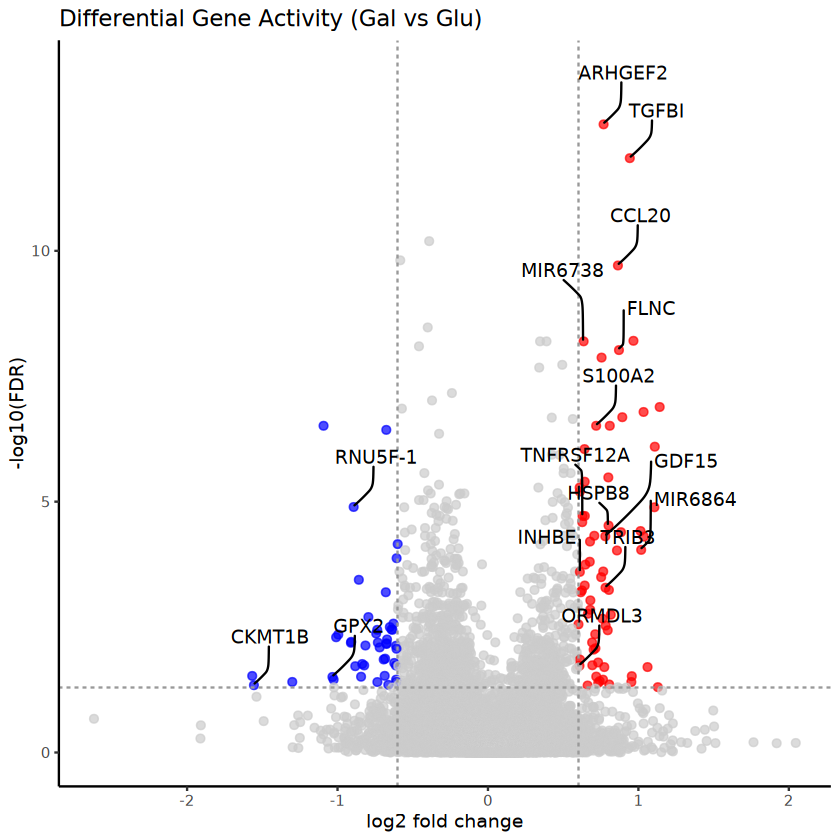

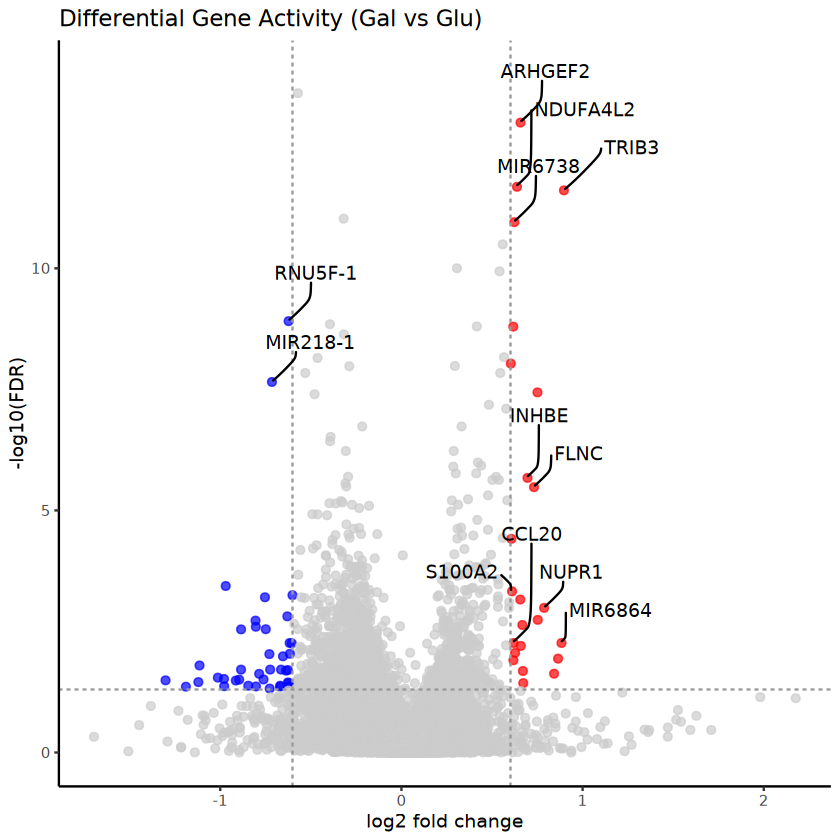

In [12]:
markerC1 <- getMarkers(markerTestC1, cutOff = "FDR <= 1 & abs(Log2FC) >= 0")
VP_C1 <- plotVP(as.data.frame(markerC1$KI36_Gal_3D)) 
VP_C1
write.csv(as.data.frame(markerC1$KI36_Gal_3D), "../output/5_DA_Gal_vs_Glu_C1.csv", quote = FALSE, row.names = TRUE)
ggsave(plot = VP_C1, "../plot/5_VolcanoPlot_Gal_vs_Glu_C1.pdf", width = 5, height = 5)

markerC3 <- getMarkers(markerTestC3, cutOff = "FDR <= 1 & abs(Log2FC) >= 0")
VP_C3 <- plotVP(as.data.frame(markerC3$KI36_Gal_3D)) 
VP_C3
write.csv(as.data.frame(markerC3$KI36_Gal_3D), "../output/5_DA_Gal_vs_Glu_C3.csv", quote = FALSE, row.names = TRUE)
ggsave(plot = VP_C3, "../plot/5_VolcanoPlot_Gal_vs_Glu_C3.pdf", width = 5, height = 5)

In [13]:
table(Gal_KI36$hash.ID)


KI36_Gal_1D KI36_Gal_3D    KI36_Glu 
       1931        2667        2819 

In [14]:
Gal_KI36$group <- case_when(Gal_KI36$hash.ID == "KI36_Gal_1D" ~ "2_KI36_Gal_1D",
                              Gal_KI36$hash.ID == "KI36_Gal_3D" ~ "3_KI36_Gal_3D",
                              Gal_KI36$hash.ID == "KI36_Glu" ~ "1_KI36_Glu")

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-1fc56154a55c6b-Date-2025-11-27_Time-10-05-03.148748.log
If there is an issue, please report to github with logFile!

2025-11-27 10:05:03.20936 : Validating Region, 0.001 mins elapsed.



GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |     gene_id      symbol
         <Rle>         <IRanges>  <Rle> | <character> <character>
  [1]    chr19 18382170-18389176      + |        9518       GDF15
  -------
  seqinfo: 24 sequences from hg38 genome


2025-11-27 10:05:03.284795 : Adding Bulk Tracks (1 of 1), 0.002 mins elapsed.

Getting Region From Arrow Files 1 of 2

Getting Region From Arrow Files 2 of 2

2025-11-27 10:05:08.183815 : Adding Gene Tracks (1 of 1), 0.084 mins elapsed.

2025-11-27 10:05:08.57904 : Plotting, 0.091 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotBrowserTrack-1fc56154a55c6b-Date-2025-11-27_Time-10-05-03.148748.log



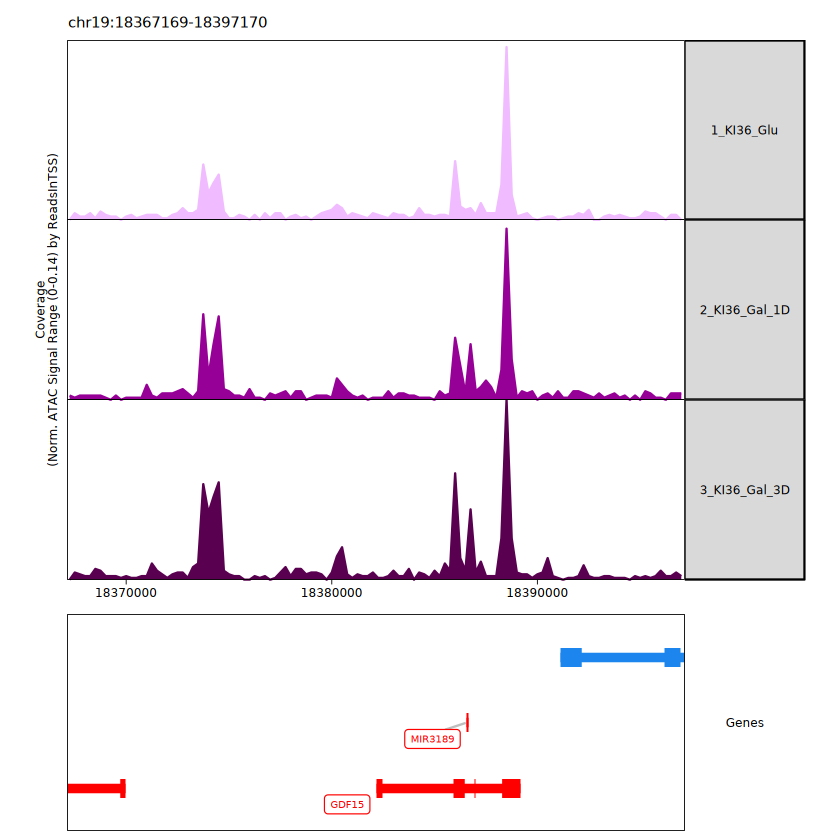

In [20]:
p <-  plotBrowserTrack(
  ArchRProj = Gal_KI36, 
  groupBy = "group", 
  geneSymbol = "GDF15", 
  upstream = 15000, # 10000
  downstream = 15000,
  pal = c("1_KI36_Glu"    = "#F0BBFF",
  "2_KI36_Gal_1D" = "#960096",
  "3_KI36_Gal_3D" = "#5A0050")
)
grid::grid.newpage()
grid::grid.draw(p$GDF15)

In [21]:
plotPDF(plotList = p, 
        name = "GDF15-Tracks-Marker-Genes_2.pdf", 
        ArchRProj = Gal_KI36, 
        addDOC = FALSE, width = 4, height = 4)

Plotting Gtable!



NULL


ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-1fc5611d1b34d0-Date-2025-11-27_Time-10-12-12.335049.log
If there is an issue, please report to github with logFile!

2025-11-27 10:12:12.396542 : Validating Region, 0.001 mins elapsed.



GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |     gene_id      symbol
         <Rle>         <IRanges>  <Rle> | <character> <character>
  [1]    chr19 18382170-18389176      + |        9518       GDF15
  -------
  seqinfo: 24 sequences from hg38 genome


2025-11-27 10:12:12.471981 : Adding Bulk Tracks (1 of 1), 0.002 mins elapsed.

Getting Region From Arrow Files 1 of 2

Getting Region From Arrow Files 2 of 2

2025-11-27 10:12:16.336162 : Adding Gene Tracks (1 of 1), 0.067 mins elapsed.

2025-11-27 10:12:16.662645 : Plotting, 0.072 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotBrowserTrack-1fc5611d1b34d0-Date-2025-11-27_Time-10-12-12.335049.log



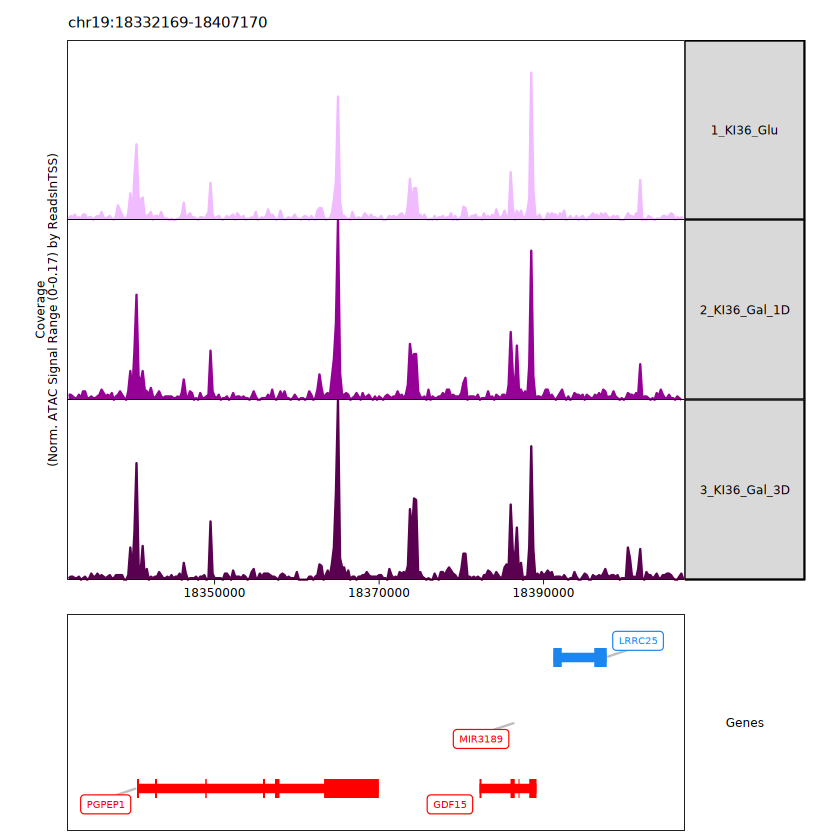

In [22]:
p <-  plotBrowserTrack(
  ArchRProj = Gal_KI36, 
  groupBy = "group", 
  geneSymbol = "GDF15", 
  upstream = 50000,
  downstream = 25000,
  pal = c("1_KI36_Glu"    = "#F0BBFF",
  "2_KI36_Gal_1D" = "#960096",
  "3_KI36_Gal_3D" = "#5A0050")
)
grid::grid.newpage()
grid::grid.draw(p$GDF15)